In [1]:
using Random
using Statistics
using Plots

In [2]:
f(x) = 5 - 24x + 17x^2 - (11/3)*x^3 + (1/4)*x^4

# --- Дискретизация x ---
# Вариант 1 (целые):   DX = 1.0
# Вариант 2 (по заданию): DX = 0.01
const X_MIN = 0.0
const X_MAX = 7.0
const DX_1 = 0.01
const DX_2 = 1
# индекс кодирует значение x = X_MIN + idx*DX
const MAX_INT_1 = round(Int, (X_MAX - X_MIN) / DX_1)
const N_BITS_1 = ceil(Int, log2(MAX_INT_1 + 1))
const MAX_INT_2 = round(Int, (X_MAX - X_MIN) / DX_2)
const N_BITS_2 = ceil(Int, log2(MAX_INT_2 + 1))


const POP_SIZE = 10
const N_GENERATIONS = 60
const P_CROSS = 0.9
const P_MUT = 0.3
const P_BITFLIP_1 = 1/N_BITS_1
const P_BITFLIP_2 = 1/N_BITS_2
const ELITE = 2

Random.seed!(42)

TaskLocalRNG()

In [3]:
# --- Вспомогательные функции (параметризованные под 2 варианта) ---

"""Преобразовать целое x в вектор битов длины nbits (MSB→LSB)."""
function int_to_bits(x::Int; nbits::Int)
    @assert 0 <= x <= (2^nbits - 1)
    bits = falses(nbits)
    for i in 1:nbits
        shift = nbits - i
        bits[i] = ((x >> shift) & 0x01) == 1
    end
    return bits
end

"""Преобразовать вектор битов (MSB→LSB) в целое."""
function bits_to_int(bits::AbstractVector{Bool})
    x = 0
    for b in bits
        x = (x << 1) | (b ? 1 : 0)
    end
    return x
end

"""Случайная хромосома длины nbits."""
random_chromosome(nbits::Int) = rand(Bool, nbits)

"""Декодировать хромосому в x на [X_MIN,X_MAX] с шагом dx."""
function decode_x(bits::AbstractVector{Bool}, dx::Real, max_int::Int)
    idx = clamp(bits_to_int(bits), 0, max_int)
    return X_MIN + idx * dx
end

"""Приспособленность для минимизации f: максимизируем -f."""
fitness(bits::AbstractVector{Bool}, dx::Real, max_int::Int) = -f(decode_x(bits, dx, max_int))


fitness

In [4]:
"""Турнирный отбор (k=3) возвращает индекс выбранной особи."""
function tournament_select(fits::AbstractVector{<:Real}; k::Int=3)
    idxs = rand(1:length(fits), k)
    best = idxs[1]
    for i in idxs[2:end]
        if fits[i] > fits[best]
            best = i
        end
    end
    return best
end

"""Одноточечный кроссинговер. point∈1:(nbits-1)."""
function one_point_crossover(p1::Vector{Bool}, p2::Vector{Bool})
    n = length(p1)
    @assert n == length(p2)
    @assert n >= 2

    if rand() > P_CROSS
        return copy(p1), copy(p2), 0
    end

    point = rand(1:n-1)
    c1 = vcat(p1[1:point], p2[point+1:end])
    c2 = vcat(p2[1:point], p1[point+1:end])
    return c1, c2, point
end

"""Мутация: с вероятностью P_MUT для потомка, затем инверсия каждого бита с p_bitflip."""
function mutate!(child::Vector{Bool}, p_bitflip::Real)
    if rand() <= P_MUT
        for i in eachindex(child)
            if rand() <= p_bitflip
                child[i] = !child[i]
            end
        end
    end
    return child
end


mutate!

In [5]:
"""Запуск ГА для конкретного варианта.

Параметры варианта:
- dx: шаг дискретизации x
- max_int: максимум индекса (0..max_int)
- nbits: длина хромосомы
- p_bitflip: вероятность инверсии бита
"""
function run_ga_variant(; dx::Real, max_int::Int, nbits::Int, p_bitflip::Real,
                        pop_size::Int=POP_SIZE, generations::Int=N_GENERATIONS)
    population = [random_chromosome(nbits) for _ in 1:pop_size]

    history = Vector{Vector{Vector{Bool}}}()
    push!(history, deepcopy(population))

    best_bits = copy(population[1])
    best_fit = fitness(best_bits, dx, max_int)

    for _gen in 1:generations
        fits = [fitness(ch, dx, max_int) for ch in population]

        order = sortperm(fits, rev=true)
        elites = [copy(population[i]) for i in order[1:ELITE]]

        if fits[order[1]] > best_fit
            best_fit = fits[order[1]]
            best_bits = copy(population[order[1]])
        end

        new_pop = Vector{Vector{Bool}}()
        append!(new_pop, elites)

        while length(new_pop) < pop_size
            p1 = population[tournament_select(fits)]
            p2 = population[tournament_select(fits)]
            c1, c2, _point = one_point_crossover(p1, p2)
            mutate!(c1, p_bitflip)
            if length(new_pop) < pop_size
                push!(new_pop, c1)
            end
            if length(new_pop) < pop_size
                mutate!(c2, p_bitflip)
                push!(new_pop, c2)
            end
        end

        population = new_pop
        push!(history, deepcopy(population))
    end

    best_x = decode_x(best_bits, dx, max_int)
    return history, best_bits, best_x, f(best_x)
end

# --- Запускаем два варианта без изменения констант ---

# 1) СНАЧАЛА целые (DX_2 = 1)
history_int, best_bits_int, best_x_int, min_f_int = run_ga_variant(
    dx=DX_2, max_int=MAX_INT_2, nbits=N_BITS_2, p_bitflip=P_BITFLIP_2,
    pop_size=POP_SIZE, generations=N_GENERATIONS,
)

# 2) Потом шаг 0.01 (DX_1 = 0.01)
history_001, best_bits_001, best_x_001, min_f_001 = run_ga_variant(
    dx=DX_1, max_int=MAX_INT_1, nbits=N_BITS_1, p_bitflip=P_BITFLIP_1,
    pop_size=POP_SIZE, generations=N_GENERATIONS,
)

(
    variant_int = (best_x=best_x_int, min_f=min_f_int, n_bits=N_BITS_2, dx=DX_2),
    variant_001 = (best_x=best_x_001, min_f=min_f_001, n_bits=N_BITS_1, dx=DX_1),
)

(variant_int = (best_x = 1.0, min_f = -5.416666666666666, n_bits = 3, dx = 1), variant_001 = (best_x = 1.0, min_f = -5.416666666666666, n_bits = 10, dx = 0.01))

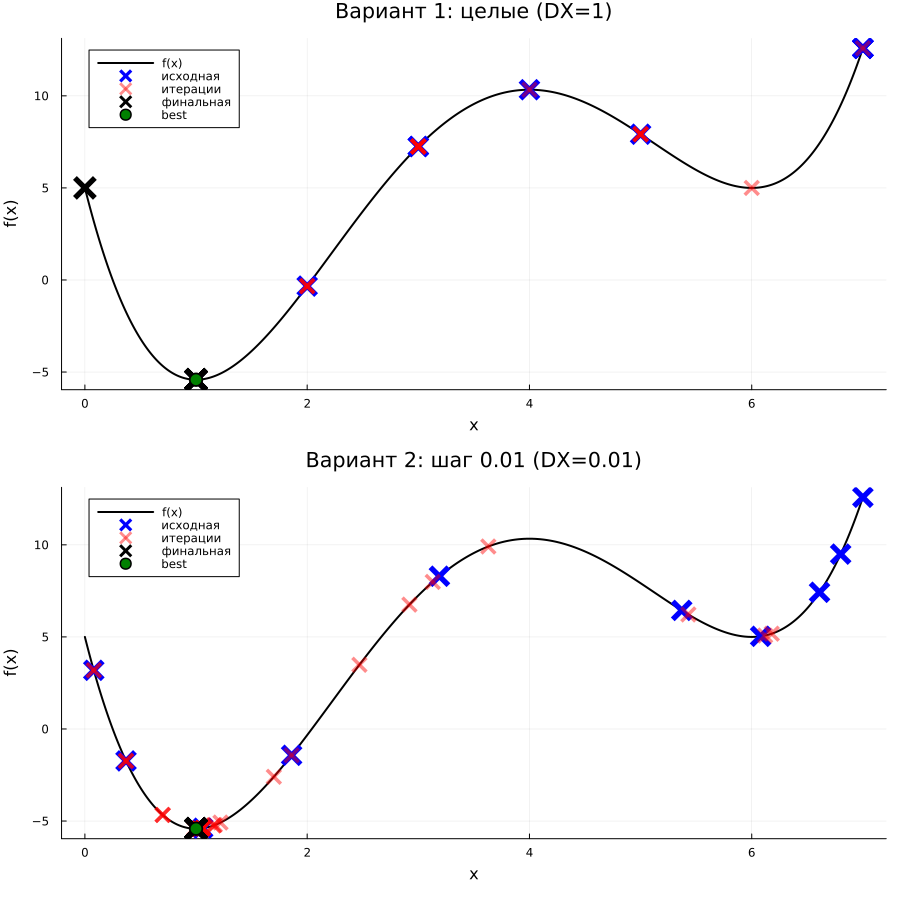

In [6]:
# --- Визуализация: два варианта (сверху целые, снизу шаг 0.01) ---

"""Собрать точки (x, f(x)) для популяции конкретного варианта."""
function pop_points(pop::Vector{Vector{Bool}}, dx::Real, max_int::Int)
    xs = [decode_x(ch, dx, max_int) for ch in pop]
    ys = f.(xs)
    return xs, ys
end

function plot_variant(history, best_x; dx::Real, max_int::Int, title::String)
    # функцию рисуем по плотной сетке, чтобы кривая была гладкой
    xgrid = collect(X_MIN:0.001:X_MAX)
    ygrid = f.(xgrid)

    p = plot(xgrid, ygrid; lw=2, label="f(x)", color=:black, title=title, xlabel="x", ylabel="f(x)")

    xs0, ys0 = pop_points(history[1], dx, max_int)
    scatter!(p, xs0, ys0; markershape=:x, ms=9, markerstrokewidth=3, color=:blue, label="исходная")

    if length(history) > 2
        sample_every = max(1, floor(Int, (length(history)-2)/10))
        for i in 2:sample_every:(length(history)-1)
            xs, ys = pop_points(history[i], dx, max_int)
            scatter!(p, xs, ys; markershape=:x, ms=7, markerstrokewidth=2, color=:red, alpha=0.45, label=(i==2 ? "итерации" : ""))
        end
    end

    xsF, ysF = pop_points(history[end], dx, max_int)
    scatter!(p, xsF, ysF; markershape=:x, ms=10, markerstrokewidth=3, color=:black, label="финальная")

    scatter!(p, [best_x], [f(best_x)]; markershape=:circle, ms=7, color=:green, label="best")
    return p
end

p1 = plot_variant(history_int, best_x_int; dx=DX_2, max_int=MAX_INT_2, title="Вариант 1: целые (DX=1)")
p2 = plot_variant(history_001, best_x_001; dx=DX_1, max_int=MAX_INT_1, title="Вариант 2: шаг 0.01 (DX=0.01)")
plot(p1, p2; layout=(2, 1), size=(900, 900))


[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\let6\ga_int.gif


Plots.AnimatedGif("D:\\Programming\\Projects\\8 Semestr\\Optimization\\let6\\ga_int.gif")
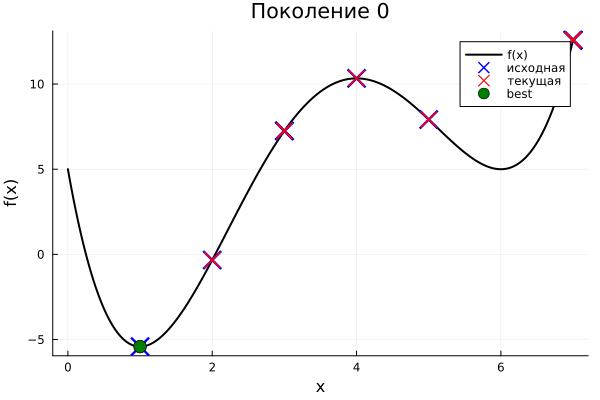

In [7]:
function filter_out_best(xs, ys, bx, by)
    keep = [(x != bx) || (y != by) for (x, y) in zip(xs, ys)]
    return xs[keep], ys[keep]
end


function gif_variant(history, best_x; dx::Real, max_int::Int, outname::String, fps::Int=8)
    # функцию рисуем по плотной сетке, чтобы кривая была гладкой
    xgrid = collect(X_MIN:0.001:X_MAX)
    ygrid = f.(xgrid)

    xs0, ys0 = pop_points(history[1], dx, max_int)
    bx, by = best_x, f(best_x)

    anim = @animate for i in 1:length(history)
        xs, ys = pop_points(history[i], dx, max_int)
        xs2, ys2 = filter_out_best(xs, ys, bx, by)

        pi = plot(xgrid, ygrid; lw=2, label="f(x)", color=:black,
                  title="Поколение $(i-1)", xlabel="x", ylabel="f(x)", legend=:topright)

        scatter!(pi, xs0, ys0; markershape=:x, ms=9, markerstrokewidth=3, color=:blue, label="исходная")

        if i < length(history)
            scatter!(pi, xs2, ys2; markershape=:x, ms=8, markerstrokewidth=2, color=:red, label="текущая")
        else
            scatter!(pi, xs2, ys2; markershape=:x, ms=10, markerstrokewidth=3, color=:black, label="финальная")
        end

        scatter!(pi, [bx], [by]; markershape=:circle, ms=7, color=:green, label="best")
        pi
    end

    return gif(anim, outname; fps=fps)
end

gif_variant(history_int, best_x_int; dx=DX_2, max_int=MAX_INT_2, outname="ga_int.gif", fps=8)

[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\let6\ga_001.gif


Plots.AnimatedGif("D:\\Programming\\Projects\\8 Semestr\\Optimization\\let6\\ga_001.gif")
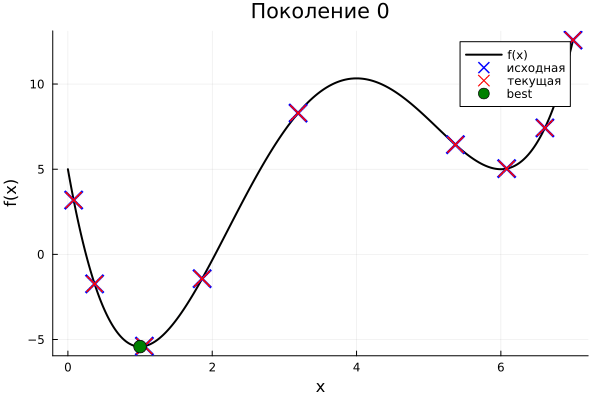

In [8]:
gif_variant(history_001, best_x_001; dx=DX_1, max_int=MAX_INT_1, outname="ga_001.gif", fps=8)